# Optimized Heart Failure Prediction

This notebook builds an optimized heart failure prediction model using the `heart.csv` dataset. It utilizes `StandardScaler` for feature scaling, `SMOTE` to balance the dataset, and a hyperparameter-tuned `Support Vector Machine (SVM)` classifier to improve classification performance.

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)
from imblearn.over_sampling import SMOTE

# Set plotting style
sns.set_theme(style="whitegrid")

### 1. Data Preprocessing & Scaling
We encode categorical variables and scale numerical variables. Scaling is critical for SVM because the algorithm is sensitive to feature magnitude, and it also helps SMOTE generate better synthetic samples.

In [11]:
# Load the dataset
df = pd.read_csv('heart.csv')

# Perform One-Hot Encoding for categorical variables
categorical_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Separate features and target variable
X = df_encoded.drop('HeartDisease', axis=1)
y = df_encoded['HeartDisease']

# Split the data into training and testing sets
# 80% for training and 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Scale numerical features only
numerical_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
scaler = StandardScaler()

X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

### 2. Apply SMOTE to Balance the Training Data
With the features scaled, SMOTE is applied to the training data to balance the target classes and reduce bias toward the majority class.

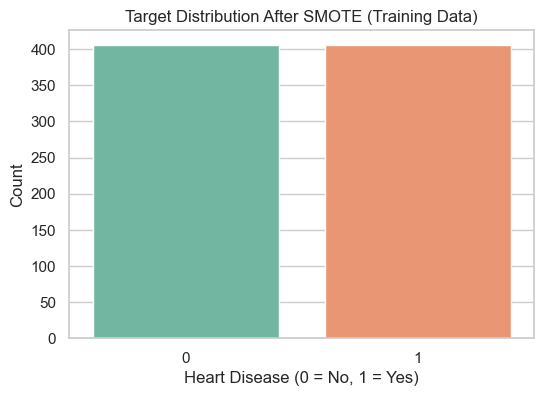

In [12]:
# Apply SMOTE to balance the training set
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Display the class distribution after SMOTE
plt.figure(figsize=(6, 4))
sns.countplot(
    x=y_train_smote,
    hue=y_train_smote,
    palette='Set2',
    legend=False
)
plt.title('Target Distribution After SMOTE (Training Data)')
plt.xlabel('Heart Disease (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

### 3. Train Optimized Support Vector Machine
We use `GridSearchCV` to test multiple hyperparameter combinations and select the best-performing SVM model for the balanced training data.

In [13]:
# Initialize the Support Vector Machine model
svm = SVC(probability=True, random_state=42)

# Define hyperparameter grid
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 0.1, 0.01, 0.001],
    'kernel': ['rbf']
}

print("Tuning model hyperparameters... This may take a moment.")

# Perform grid search with cross-validation
grid_search = GridSearchCV(
    estimator=svm,
    param_grid=param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)

# Fit grid search on the balanced training data
grid_search.fit(X_train_smote, y_train_smote)

# Store the best model
best_model = grid_search.best_estimator_

# Print best parameters
print(f"Best Parameters Found: {grid_search.best_params_}")

Tuning model hyperparameters... This may take a moment.
Best Parameters Found: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}


### 4. Evaluation and Visualizations
The optimized SVM model is evaluated on the unseen test set using accuracy, classification report, confusion matrix, and ROC curve.

Since SVM does not provide built-in feature importances like Random Forest, ROC-AUC is used as the second visualization to better assess classification performance.

Training Accuracy: 0.8953
Testing Accuracy:  0.8913
Difference:        0.0040

Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.85      0.88        82
           1       0.89      0.92      0.90       102

    accuracy                           0.89       184
   macro avg       0.89      0.89      0.89       184
weighted avg       0.89      0.89      0.89       184



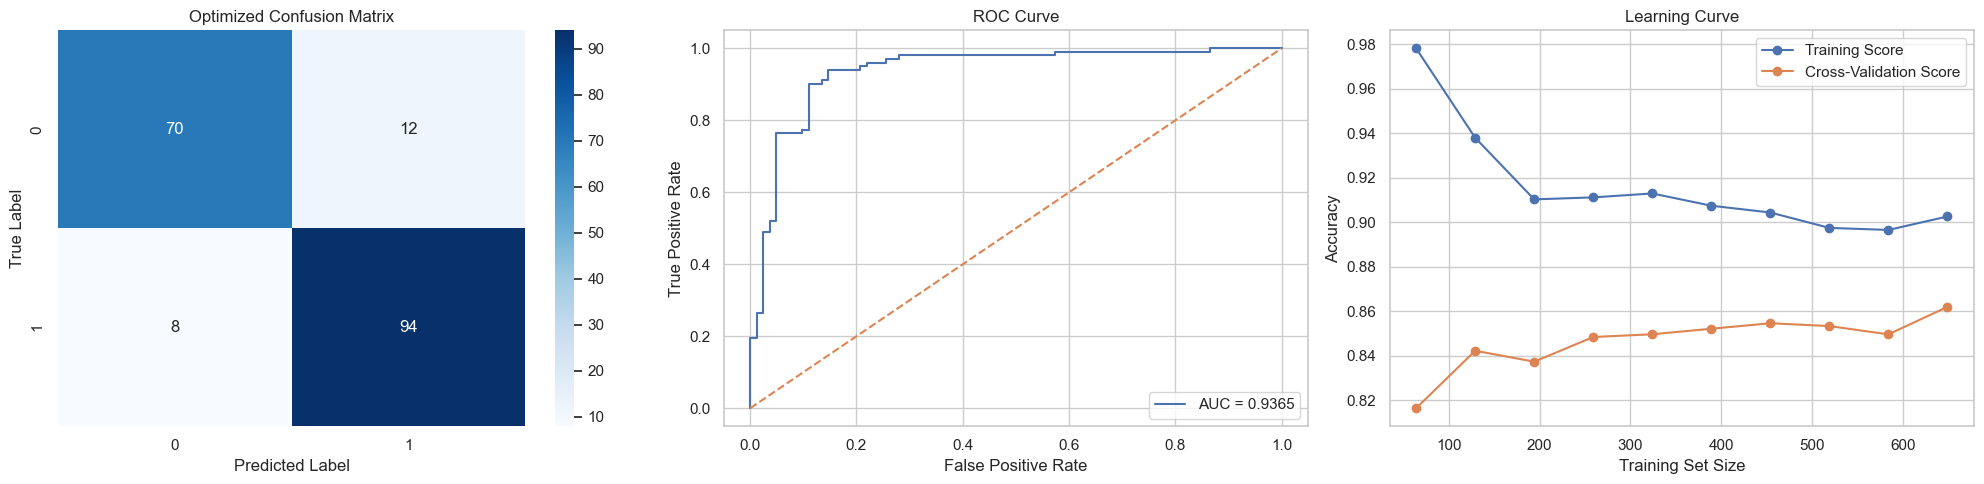

In [14]:
from sklearn.model_selection import learning_curve
import numpy as np

# Make predictions
y_train_pred = best_model.predict(X_train_smote)
y_test_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

# Accuracy values
train_accuracy = accuracy_score(y_train_smote, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)
difference = train_accuracy - test_accuracy
auc_score = roc_auc_score(y_test, y_prob)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy:  {test_accuracy:.4f}")
print(f"Difference:        {difference:.4f}\n")

print("Classification Report:\n")
print(classification_report(y_test, y_test_pred))

# Learning curve
train_sizes, train_scores, val_scores = learning_curve(
    best_model,
    X_train_smote,
    y_train_smote,
    cv=5,
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

train_scores_mean = train_scores.mean(axis=1)
val_scores_mean = val_scores.mean(axis=1)

# Plotting
fig, ax = plt.subplots(1, 3, figsize=(20, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_title('Optimized Confusion Matrix')
ax[0].set_xlabel('Predicted Label')
ax[0].set_ylabel('True Label')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
ax[1].plot(fpr, tpr, label=f'AUC = {auc_score:.4f}')
ax[1].plot([0, 1], [0, 1], linestyle='--')
ax[1].set_title('ROC Curve')
ax[1].set_xlabel('False Positive Rate')
ax[1].set_ylabel('True Positive Rate')
ax[1].legend()

# Learning Curve
ax[2].plot(train_sizes, train_scores_mean, marker='o', label='Training Score')
ax[2].plot(train_sizes, val_scores_mean, marker='o', label='Cross-Validation Score')
ax[2].set_title('Learning Curve')
ax[2].set_xlabel('Training Set Size')
ax[2].set_ylabel('Accuracy')
ax[2].legend()
ax[2].grid(True)

plt.tight_layout()
plt.show()